In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df2 = pd.read_csv('cleanedData.csv')

In [4]:
df2.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Clean Tags,Clean Categories,Clean Genres
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,0,5.24,65,"Springtime, April: when the cherry trees come ...",['English'],...,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute","['Adventure', 'Visual Novel', 'Anime', 'Cute']","['Single-player', 'Steam Trading Cards', 'Stea...",['Adventure']
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...","['Casual', 'Card Game', 'Solitaire', 'Puzzle',...","['Single-player', 'Family Sharing']",['Casual']
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0 - 20000,1,0,8.99,0,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,[],"['Single-player', 'Steam Achievements', 'Famil...","['Casual', 'Indie', 'Simulation']"
3,3631080,Maze Quest VR,2025-04-24,0 - 20000,0,0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,[],"['Single-player', 'VR Only', 'Steam Leaderboar...","['Action', 'Early Access']"
4,1654170,Agony VR,2023-04-05,0 - 20000,0,0,13.99,0,A JOURNEY THROUGH HELL! Explore the most terri...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,[],"['Single-player', 'Tracked Controller Support'...","['Action', 'Adventure']"


In [5]:
df2.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'User score', 'Positive',
       'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes',
       'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Clean Tags',
       'Clean Categories', 'Clean Genres'],
      dtype='str')

<Axes: xlabel='Release year'>

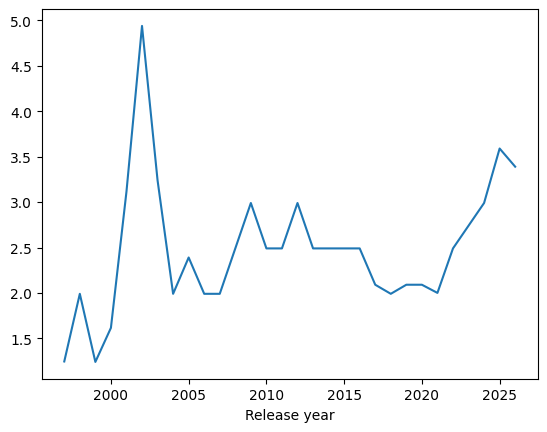

In [6]:
df2['Release year'] = df2['Release date'].apply(lambda x: x.split('-')[0]).sort_values() 
df2['Release year'] = pd.to_numeric(df2["Release year"])

df2.groupby('Release year')['Price'].median().plot(kind='line')


<Axes: xlabel='Release year'>

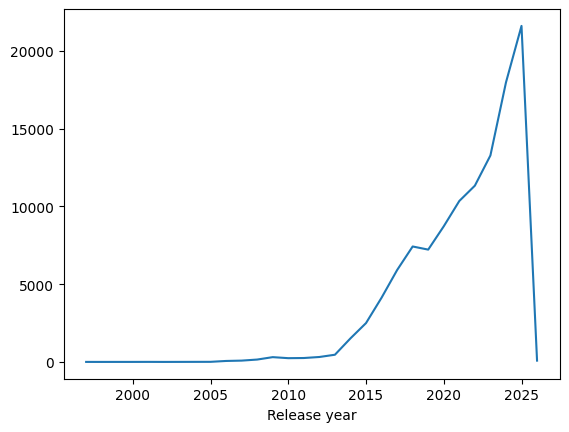

In [7]:
df2.groupby('Release year')['Name'].nunique().plot(kind='line')

In [20]:
print(df2['Price'].dtype)
print(df2['Price'].head(20))

float64
0      5.24
1      4.99
2      8.99
3      4.99
4     13.99
5     35.99
6      0.99
7      0.99
8      0.59
9      0.99
10    13.99
11     1.49
12     1.35
13     0.99
14     1.40
15     1.04
16     0.00
17     5.99
18     0.00
19     5.99
Name: Price, dtype: float64


In [8]:
import numpy as np

<Axes: >

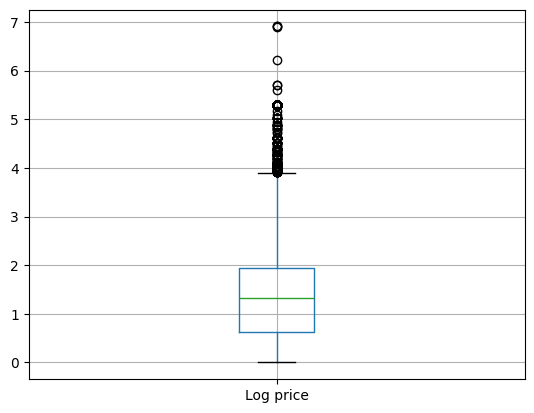

In [9]:
# since the data is right skewed and close to 0, using log1p can handle 0 values 

df2['Log price'] = np.log1p(df2['Price'])
df2.boxplot(column='Log price')

In [12]:
df2["Recommendations"].info()

<class 'pandas.Series'>
RangeIndex: 114162 entries, 0 to 114161
Series name: Recommendations
Non-Null Count   Dtype
--------------   -----
114162 non-null  int64
dtypes: int64(1)
memory usage: 892.0 KB
